# EDA – AcmeTel Customer Churn
**Tujuan:** Memahami dataset, distribusi target, kualitas data, dan pola awal sebelum modelling.

**Dataset:** WA_Fn-UseC_-Telco-Customer-Churn.csv (sumber: Kaggle / IBM Sample Data)

---
## Section 1 – Setup

In [4]:
# === Import Libraries ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# === Display Options ===
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [5]:
# === Load Dataset ===
DATA_PATH = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(DATA_PATH)
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Dataset loaded: 7,043 rows x 21 columns


---
## Section 2 – Data Overview

In [6]:
# === Head ===
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# === Shape ===
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')

Rows    : 7,043
Columns : 21


In [8]:
# === Info ===
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
# === Describe ===
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.00,7043,7043,7043.00,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.00,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.16,NaN,NaN,32.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.76,NaN,NaN
std,NaN,NaN,0.37,NaN,NaN,24.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.09,NaN,NaN
min,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.25,NaN,NaN
25%,NaN,NaN,0.00,NaN,NaN,9.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.50,NaN,NaN
50%,NaN,NaN,0.00,NaN,NaN,29.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.35,NaN,NaN
75%,NaN,NaN,0.00,NaN,NaN,55.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.85,NaN,NaN


### Catatan Data Overview
- **7.043 baris** dan **21 kolom** (termasuk `customerID` sebagai identifier non-fitur).
- **Feature numerik:** `tenure`, `MonthlyCharges`, `TotalCharges` (perlu dicek tipenya).
- **Feature kategorikal:** `Contract`, `InternetService`, `PaymentMethod`, dan banyak fitur layanan (Yes/No).
- `SeniorCitizen` bertipe int (0/1), diperlakukan sebagai biner.
- `TotalCharges` terindikasi bertipe `object` — akan dicek di Section 4.

---
## Section 3 – Target: `Churn`

In [10]:
# === Value Counts – Absolute ===
print('=== Absolute Count ===')
print(df['Churn'].value_counts())

# === Value Counts – Proporsi (normalize=True) ===
print('\n=== Proportion (normalize=True) ===')
churn_proportion = df['Churn'].value_counts(normalize=True)
print(churn_proportion.round(4))
print(f'\n→ Churn rate : {churn_proportion["Yes"]*100:.2f}%')
print(f'→ Retain rate: {churn_proportion["No"]*100:.2f}%')

=== Absolute Count ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

=== Proportion (normalize=True) ===
Churn
No    0.73
Yes   0.27
Name: proportion, dtype: float64

→ Churn rate : 26.54%
→ Retain rate: 73.46%


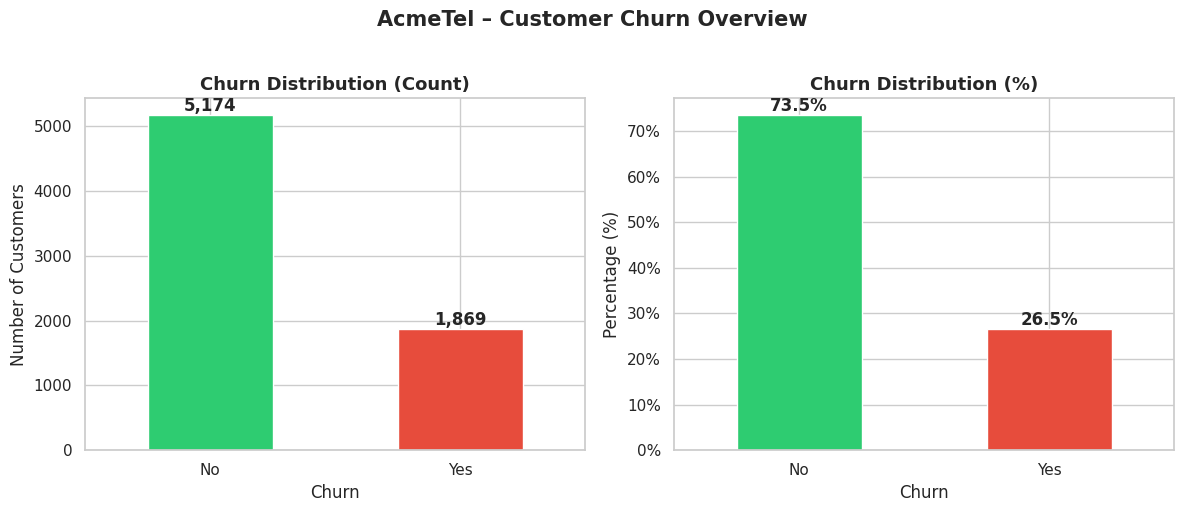

In [11]:
# === Bar Chart – Churn Distribution ===
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c']

# Plot kiri: Count
churn_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Churn Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Plot kanan: Percentage
churn_pct.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Churn Distribution (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.suptitle('AcmeTel – Customer Churn Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Insight – Target Churn
- Dataset bersifat **moderately imbalanced**: sekitar **26–27% churn** vs **73–74% tidak churn**.
- Ini bukan extreme imbalance, tapi cukup signifikan — model tidak bisa hanya dievaluasi dengan **Accuracy**.
- Metric yang relevan: **Recall** (agar customer berisiko tidak terlewat), **Precision**, **F1-Score**, dan **AUC-ROC**.
- Di fase modelling, pertimbangkan `class_weight='balanced'` atau teknik resampling (SMOTE).

---
## Section 4 – Data Quality

In [12]:
# === Missing Values – Cek NaN Eksplisit ===
missing_raw = df.isnull().sum()
print('=== NaN langsung di dataset ===')
if missing_raw.any():
    print(missing_raw[missing_raw > 0])
else:
    print('Tidak ada NaN eksplisit.')

=== NaN langsung di dataset ===
Tidak ada NaN eksplisit.


In [13]:
# === TotalCharges – Cek Tipe & Hidden Missing ===
print(f'Dtype TotalCharges sebelum konversi: {df["TotalCharges"].dtype}')

# Konversi ke numerik — string kosong/spasi menjadi NaN
tc_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_missing  = tc_numeric.isna().sum()

print(f'\ndf["TotalCharges"].isna().sum() setelah pd.to_numeric(..., errors="coerce"): {n_missing}')

if n_missing > 0:
    print(f'\nBaris dengan TotalCharges non-numerik (tenure=0, customer baru):')
    problem_rows = df[tc_numeric.isna()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
    print(problem_rows.to_string(index=False))

Dtype TotalCharges sebelum konversi: str

df["TotalCharges"].isna().sum() setelah pd.to_numeric(..., errors="coerce"): 11

Baris dengan TotalCharges non-numerik (tenure=0, customer baru):
customerID  tenure  MonthlyCharges TotalCharges Churn
4472-LVYGI       0           52.55                 No
3115-CZMZD       0           20.25                 No
5709-LVOEQ       0           80.85                 No
4367-NUYAO       0           25.75                 No
1371-DWPAZ       0           56.05                 No
7644-OMVMY       0           19.85                 No
3213-VVOLG       0           25.35                 No
2520-SGTTA       0           20.00                 No
2923-ARZLG       0           19.70                 No
4075-WKNIU       0           73.35                 No
2775-SEFEE       0           61.90                 No


In [14]:
# === Ringkasan Tipe Data & Missing ===
missing_summary = pd.DataFrame({
    'Dtype'         : df.dtypes,
    'NaN_explicit'  : df.isnull().sum(),
    'Unique_Values' : df.nunique()
})
missing_summary

,Dtype,NaN_explicit,Unique_Values
customerID,str,0,7043
gender,str,0,2
SeniorCitizen,int64,0,2
Partner,str,0,2
Dependents,str,0,2
tenure,int64,0,73
PhoneService,str,0,2
MultipleLines,str,0,3
InternetService,str,0,3
OnlineSecurity,str,0,3


### Catatan – Data Quality
- **Tidak ada NaN eksplisit** di seluruh kolom.
- **`TotalCharges` bertipe `object` (string)** dan mengandung **11 nilai non-numerik** (string spasi kosong `' '`) untuk customer baru dengan `tenure = 0`.
- Setelah `pd.to_numeric(..., errors='coerce')`, baris ini menjadi `NaN`.
- **Strategi cleaning (diputuskan di Fase 2):**
  - Opsi A: **Isi dengan 0** — logis karena `tenure=0` berarti belum ada tagihan kumulatif.
  - Opsi B: **Drop baris** — jumlahnya kecil (11 dari 7.043), dampak minimal.
- `customerID` akan di-drop saat modelling karena bukan fitur prediktif.

---
## Section 5 – Feature Exploration vs Churn

In [15]:
# === Prep: Buat ChurnFlag (Yes→1, No→0) ===
df['ChurnFlag']          = df['Churn'].map({'Yes': 1, 'No': 0})
df['TotalCharges_clean'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('ChurnFlag distribution:')
print(df['ChurnFlag'].value_counts())

ChurnFlag distribution:
ChurnFlag
0    5174
1    1869
Name: count, dtype: int64


Churn rate by Contract:
Contract
Month-to-month    42.71%
One year          11.27%
Two year           2.83%
Name: ChurnFlag, dtype: str


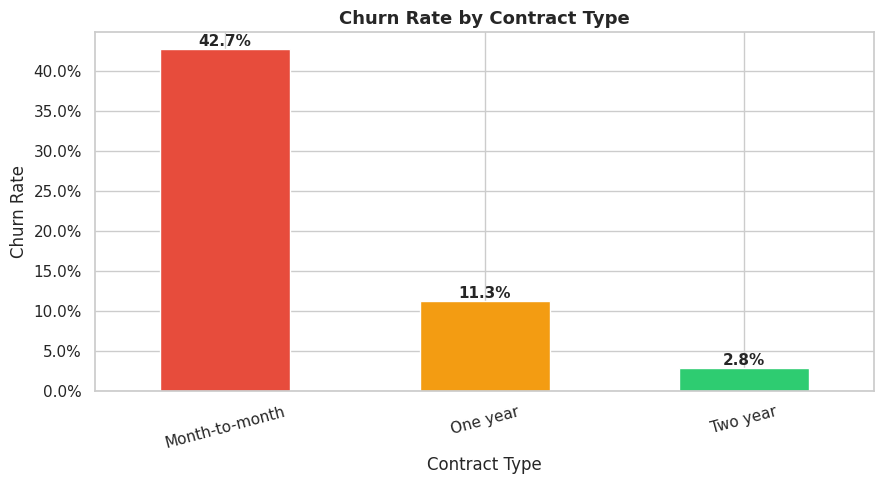

In [16]:
# === Plot 1: Churn Rate by Contract Type ===
contract_churn = df.groupby('Contract')['ChurnFlag'].mean().sort_values(ascending=False)
print('Churn rate by Contract:')
print((contract_churn * 100).round(2).astype(str) + '%')

fig, ax = plt.subplots(figsize=(9, 5))
contract_churn.plot(kind='bar', ax=ax,
                    color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white', width=0.5)
ax.set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate')
ax.tick_params(axis='x', rotation=15)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

Churn rate by Tenure bin:
tenure_bin
0-12     47.68%
13-24    28.71%
25-36    21.63%
37-48    19.03%
49-60    14.42%
61-72     6.61%
Name: ChurnFlag, dtype: str


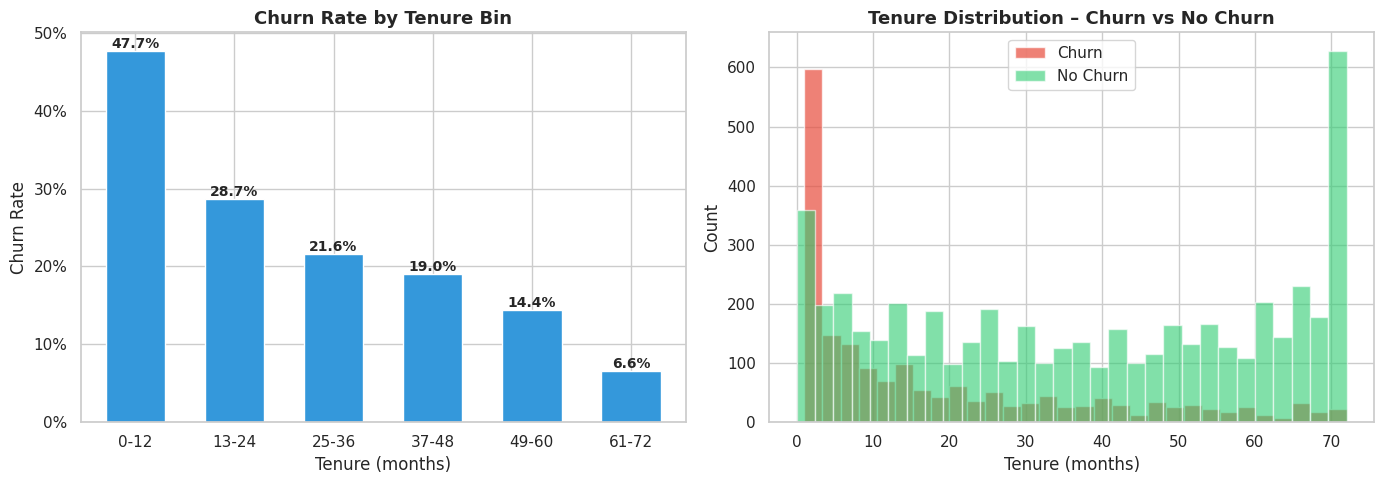


Median tenure per Churn group:
Churn
No    38.00
Yes   10.00
Name: tenure, dtype: float64


In [17]:
# === Plot 2: Churn Rate by Tenure Bin ===
df['tenure_bin'] = pd.cut(df['tenure'],
                           bins=[0, 12, 24, 36, 48, 60, 72],
                           labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72'])

tenure_churn = df.groupby('tenure_bin', observed=True)['ChurnFlag'].mean()
print('Churn rate by Tenure bin:')
print((tenure_churn * 100).round(2).astype(str) + '%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar: churn rate per bin
tenure_churn.plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='white', width=0.6)
axes[0].set_title('Churn Rate by Tenure Bin', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()*100:.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

# Histogram: distribusi tenure Churn vs No Churn
df[df['Churn']=='Yes']['tenure'].hist(bins=30, alpha=0.7, color='#e74c3c', label='Churn', ax=axes[1])
df[df['Churn']=='No']['tenure'].hist(bins=30, alpha=0.6, color='#2ecc71', label='No Churn', ax=axes[1])
axes[1].set_title('Tenure Distribution – Churn vs No Churn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nMedian tenure per Churn group:')
print(df.groupby('Churn')['tenure'].median())

Median MonthlyCharges by Churn:
Churn
No    64.43
Yes   79.65
Name: MonthlyCharges, dtype: float64


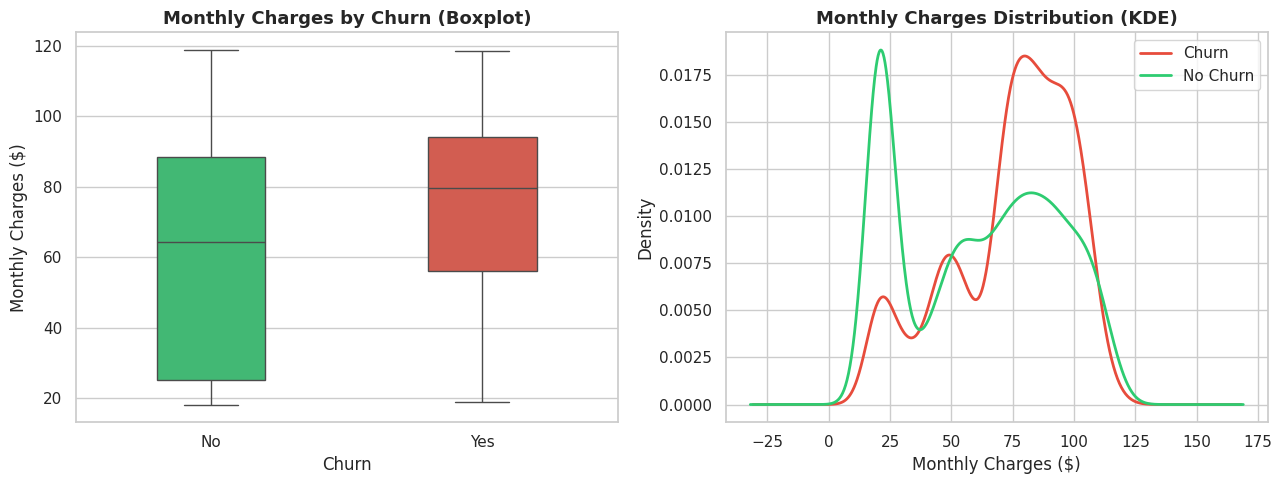

In [18]:
# === Plot 3: MonthlyCharges – Boxplot & KDE ===
print('Median MonthlyCharges by Churn:')
print(df.groupby('Churn')['MonthlyCharges'].median())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, width=0.4, ax=axes[0])
axes[0].set_title('Monthly Charges by Churn (Boxplot)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Monthly Charges ($)')

# KDE
df[df['Churn']=='Yes']['MonthlyCharges'].plot(
    kind='kde', ax=axes[1], color='#e74c3c', label='Churn', linewidth=2)
df[df['Churn']=='No']['MonthlyCharges'].plot(
    kind='kde', ax=axes[1], color='#2ecc71', label='No Churn', linewidth=2)
axes[1].set_title('Monthly Charges Distribution (KDE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

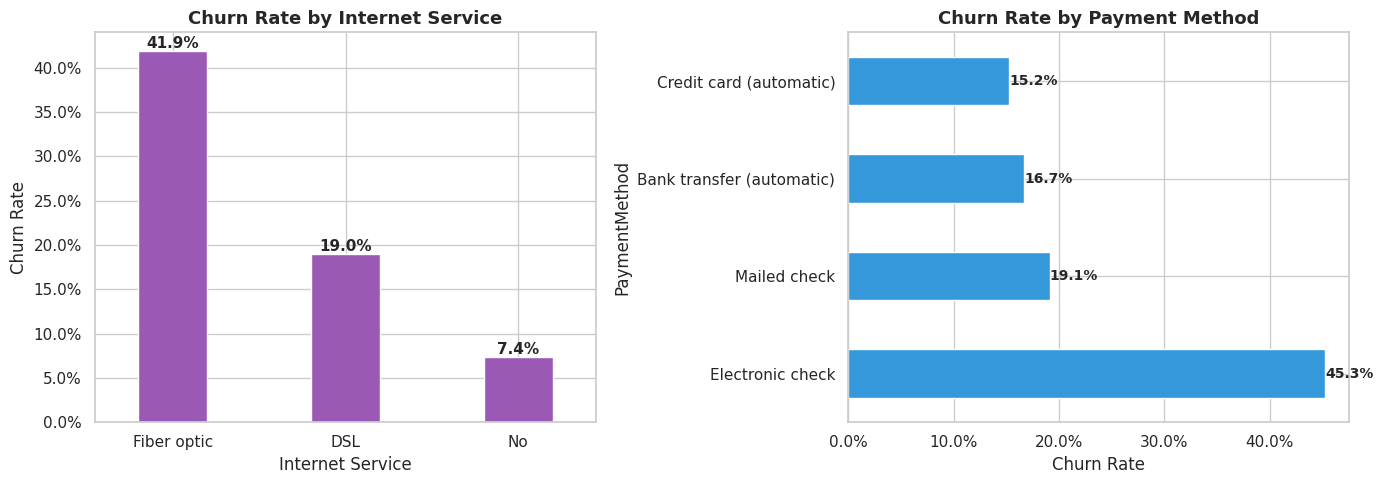

In [19]:
# === Plot 4: Internet Service & Payment Method ===
internet_churn = df.groupby('InternetService')['ChurnFlag'].mean().sort_values(ascending=False)
payment_churn  = df.groupby('PaymentMethod')['ChurnFlag'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

internet_churn.plot(kind='bar', ax=axes[0], color='#9b59b6', edgecolor='white', width=0.4)
axes[0].set_title('Churn Rate by Internet Service', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Internet Service')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()*100:.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

payment_churn.plot(kind='barh', ax=axes[1], color='#3498db', edgecolor='white')
axes[1].set_title('Churn Rate by Payment Method', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churn Rate')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_width()*100:.1f}%',
                     (p.get_width(), p.get_y() + p.get_height()/2),
                     ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
# === Tabel Ringkasan: Churn Rate per Feature Utama ===
for name, col in [('Contract', 'Contract'), ('Tenure Bin', 'tenure_bin'), ('Internet Service', 'InternetService')]:
    tbl = df.groupby(col, observed=True)['ChurnFlag'].agg(['mean', 'count'])
    tbl.columns = ['churn_rate', 'n']
    tbl['churn_rate_%'] = (tbl['churn_rate'] * 100).round(2)
    print(f'\n--- {name} ---')
    print(tbl[['n', 'churn_rate_%']].to_string())


--- Contract ---
                   n  churn_rate_%
Contract                          
Month-to-month  3875         42.71
One year        1473         11.27
Two year        1695          2.83

--- Tenure Bin ---
               n  churn_rate_%
tenure_bin                    
0-12        2175         47.68
13-24       1024         28.71
25-36        832         21.63
37-48        762         19.03
49-60        832         14.42
61-72       1407          6.61

--- Internet Service ---
                    n  churn_rate_%
InternetService                    
DSL              2421         18.96
Fiber optic      3096         41.89
No               1526          7.40


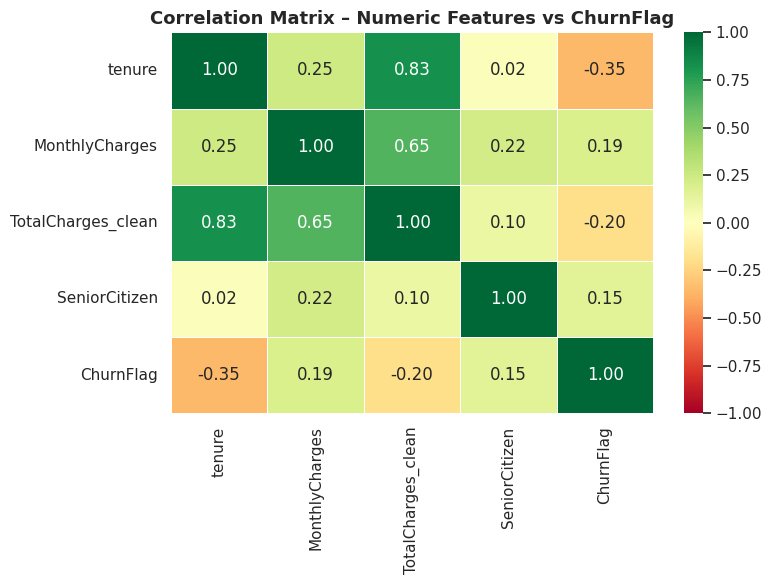

In [21]:
# === Correlation Heatmap (Numerik) ===
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges_clean', 'SeniorCitizen', 'ChurnFlag']

fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix – Numeric Features vs ChurnFlag', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Key EDA Insights

> Ringkasan ini adalah dasar untuk design feature, pemilihan metric, dan komunikasi ke stakeholder.

**1. Dataset Moderately Imbalanced — Churn Rate ~26–27%**
Hanya sekitar 1 dari 4 pelanggan yang churn. Ini adalah moderate imbalance — model tidak boleh dievaluasi hanya dengan Accuracy. Recall dan AUC-ROC menjadi metric utama karena cost of missing a churner (false negative) jauh lebih mahal secara bisnis dibanding false positive.

**2. Kontrak Month-to-Month = Risiko Churn Tertinggi (~42%)**
Pelanggan dengan kontrak month-to-month memiliki churn rate jauh lebih tinggi (~42%) dibanding one year (~11%) atau two year (~3%). Ini adalah feature paling diskriminatif. Dari sisi bisnis: mendorong pelanggan beralih ke kontrak tahunan adalah intervensi retensi paling langsung.

**3. Customer Baru (Tenure < 12 Bulan) Churn Paling Tinggi**
Median tenure pelanggan yang churn hanya ~10 bulan vs ~37 bulan untuk yang tidak churn. Pelanggan di tahun pertama adalah segmen paling kritis. Program onboarding dan early retention perlu diperkuat untuk kelompok ini.

**4. MonthlyCharges Lebih Tinggi pada Pelanggan yang Churn**
Pelanggan yang churn membayar tagihan bulanan median ~$74 vs ~$61 untuk yang tidak churn. Pelanggan dengan tagihan tinggi justru lebih berisiko — kemungkinan berkaitan dengan paket Fiber Optic yang lebih mahal.

**5. Fiber Optic = Churn Rate Tertinggi per Jenis Internet (~41%)**
Pengguna Fiber Optic memiliki churn rate ~41%, jauh di atas DSL (~19%) dan No Internet (~7%). Perlu investigasi lebih lanjut: apakah karena harga, kualitas layanan, atau kompetitor yang lebih agresif di segmen ini.

---
**Next Step (Fase 2):** Cleaning `TotalCharges`, encoding kategorikal, train-test split, dan baseline model (Logistic Regression + Random Forest).